In [2]:
# pip install tensorflow
# pip install tensorflow-hub
# pip install tensorflow-datasets


import numpy as np

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

import matplotlib.pyplot as plt

print("Version: ", tf.__version__)
print("Eager mode: ", tf.executing_eagerly())
print("Hub version: ", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

Version:  2.20.0
Eager mode:  True
Hub version:  0.16.1
GPU is NOT AVAILABLE


In [3]:
# The IMDB dataset is available on TensorFlow datasets. 
# The following code downloads the IMDB dataset to your machine (or the colab runtime):

train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"], 
                                  batch_size=-1, as_supervised=True)

train_examples, train_labels = tfds.as_numpy(train_data)
test_examples, test_labels = tfds.as_numpy(test_data)

In [4]:
# Explore the dataExplore the data
# 
print("Training entries: {}, test entries: {}".format(len(train_examples), len(test_examples)))

Training entries: 25000, test entries: 25000


In [6]:
# Let's print first 10 examples.
train_examples[:10]

array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot 

In [7]:
# Let's also print the first 10 labels.
train_labels[:10]

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0])

In [8]:
# Example 2

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Sample text
sentences = [
    'Hello, how are you?',
    'I am learning Natural Language Processing.',
    'It involves tasks such as tokenization.'
]

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")

# Fit the tokenizer on the sentences
tokenizer.fit_on_texts(sentences)

# Get the word index
word_index = tokenizer.word_index

# Tokenize the sentences
sequences = tokenizer.texts_to_sequences(sentences)

print(word_index)
print(sequences)

{'<OOV>': 1, 'hello': 2, 'how': 3, 'are': 4, 'you': 5, 'i': 6, 'am': 7, 'learning': 8, 'natural': 9, 'language': 10, 'processing': 11, 'it': 12, 'involves': 13, 'tasks': 14, 'such': 15, 'as': 16, 'tokenization': 17}
[[2, 3, 4, 5], [6, 7, 8, 9, 10, 11], [12, 13, 14, 15, 16, 17]]


In [9]:
# Bag-of-Words Representations in TensorFlow

import tensorflow as tf
import numpy as np
text_data = [
    "The cat sat on the mat.",
    "The dog lay on the rug."
]
# Set parameters
max_tokens = 10  
output_mode = "count" 

# Create the vectorization layer
vectorizer = tf.keras.layers.TextVectorization(max_tokens=max_tokens, output_mode=output_mode)

# Adapt the vectorizer to the dataset
vectorizer.adapt(text_data)
bow_representation = vectorizer(text_data)

# Display results
print("Vocabulary:", vectorizer.get_vocabulary())
print("Bag-of-Words Representation:\n", bow_representation.numpy())


Vocabulary: ['[UNK]', np.str_('the'), np.str_('on'), np.str_('sat'), np.str_('rug'), np.str_('mat'), np.str_('lay'), np.str_('dog'), np.str_('cat')]
Bag-of-Words Representation:
 [[0 2 1 1 0 1 0 0 1]
 [0 2 1 0 1 0 1 1 0]]


In [10]:
# Bag-of-Words Representations in TensorFlow
# output mode "tf-idf"

import tensorflow as tf
import numpy as np
text_data = [
    "The cat sat on the mat.",
    "The dog lay on the rug."
]
# Set parameters
max_tokens = 10  
output_mode = "tf-idf"

# Create the vectorization layer
vectorizer = tf.keras.layers.TextVectorization(max_tokens=max_tokens, output_mode=output_mode)

# Adapt the vectorizer to the dataset
vectorizer.adapt(text_data)
bow_representation = vectorizer(text_data)

# Display results
print("Vocabulary:", vectorizer.get_vocabulary())
print("Bag-of-Words Representation:\n", bow_representation.numpy())


Vocabulary: ['[UNK]', np.str_('the'), np.str_('on'), np.str_('sat'), np.str_('rug'), np.str_('mat'), np.str_('lay'), np.str_('dog'), np.str_('cat')]
Bag-of-Words Representation:
 [[0.         1.0216513  0.51082563 0.6931472  0.         0.6931472
  0.         0.         0.6931472 ]
 [0.         1.0216513  0.51082563 0.         0.6931472  0.
  0.6931472  0.6931472  0.        ]]


In [11]:
# Bag-of-Words Representations in TensorFlow
# output mode "int"

import tensorflow as tf
import numpy as np
text_data = [
    "The cat sat on the mat.",
    "The dog lay on the rug."
]
# Set parameters
max_tokens = 10  
output_mode = "int"

# Create the vectorization layer
vectorizer = tf.keras.layers.TextVectorization(max_tokens=max_tokens, output_mode=output_mode)

# Adapt the vectorizer to the dataset
vectorizer.adapt(text_data)
bow_representation = vectorizer(text_data)

# Display results
print("Vocabulary:", vectorizer.get_vocabulary())
print("Bag-of-Words Representation:\n", bow_representation.numpy())


Vocabulary: ['', '[UNK]', np.str_('the'), np.str_('on'), np.str_('sat'), np.str_('rug'), np.str_('mat'), np.str_('lay'), np.str_('dog'), np.str_('cat')]
Bag-of-Words Representation:
 [[2 9 4 3 2 6]
 [2 8 7 3 2 5]]


# Object Detection

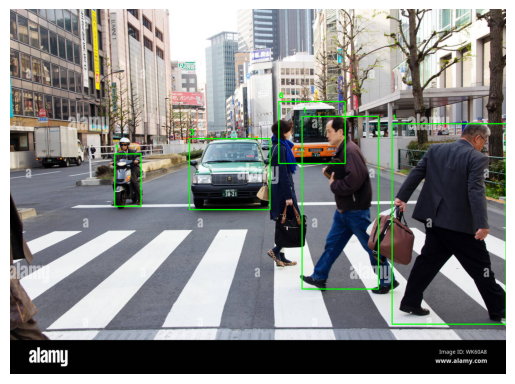

In [14]:
# Object Detection
# pip install opencv-python

import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
# model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/fpnlite_320x320/1")
# Read image (OpenCV loads as uint8 automatically)
image_path = "C://Users/kumar/Downloads/trafic5.jpg"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to tensor WITHOUT resizing or normalization
input_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
input_tensor = tf.expand_dims(input_tensor, axis=0)

# Run detection
outputs = model(input_tensor)

# Extract outputs
boxes = outputs["detection_boxes"][0].numpy()
scores = outputs["detection_scores"][0].numpy()
classes = outputs["detection_classes"][0].numpy().astype(int)

height, width, _ = img.shape

# Draw bounding boxes
for i in range(len(scores)):
    if scores[i] > 0.5:
        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1 = int(xmin * width), int(ymin * height)
        x2, y2 = int(xmax * width), int(ymax * height)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{classes[i]}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0, 255, 0), 2)

# Display
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

